# Return-to-Office — a quantitative teardown 🔬
### Basket market-model CAR by strict/hybrid bucket · strict−hybrid Welch *t* + a placebo basket-window null · window & VNQ-benchmark robustness · a 1-day-lag tradable variant + costs · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Office_rebound%3F: Not_supported](https://img.shields.io/badge/Office_rebound%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **sector event-study hypothesis** — a positive abnormal reaction of an office-REIT basket around an RTO mandate, larger for *strict* mandates — and confront it with the **sample size**, the **benchmark choice**, and **survivorship**. The decisive objects are a cross-section of ~26 basket CARs and a placebo null sized to that count.

> ⚠️ **Data + survivorship note.** The RTO calendar is hardcoded and transparent (~26 real, dated mandates); the priced basket is **survivor-biased** — the worst landlords (WeWork, CMBS-default towers) **delisted**, biasing the reaction *toward zero* (named on the Signal axis). Real data: yfinance daily closes for 10 office REITs + SPY + VNQ, 2018→2026. The Kastle occupancy series is a **labelled proxy**, never priced. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from return_to_office import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
MEM = data.members_present(PRICES) if HAVE_REAL else data.OFFICE_REITS
PANEL = st.car_panel(PRICES, EVENTS, MEM) if HAVE_REAL else None
print("real office-basket cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)),
      "| basket members:", len(MEM))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 26, 'n_strict': 18, 'n_hybrid': 8, 'n_priced': 26, 'asof': '2026-07-10', 'fp': '69ca30fe1b8b', 'n_delisted': 3, 'n_members': 10, 'strict': (18, -0.34, 44, -0.49), 'hybrid': (8, -0.43, 50, -0.52), 'allb': (26, -0.37, 46, -0.69), 'diff_pp': 0.09, 'diff_t': 0.08, 'placebo_p': 0.53, 'null_mean': 0.0, 'robust': [('[0,0]', 0.23, 0.69, 0.5, 0.8), ('[0,+2]', -0.37, -0.69, 0.09, 0.08), ('[-1,+1]', 0.3, 0.5, -0.52, -0.37), ('[0,+4]', 0.14, 0.18, 1.9, 1.32)], 'vnq': [('[0,0]', 0.21, 0.85), ('[0,+2]', 0.17, 0.43)], 'trade': [('[+1,+3]', -0.33, -0.47, -0.43), ('[+1,+5]', -0.78, -0.88, -0.88)], 'syn': [(0, 1.29, 1.87, 0.93, 1.01), (400, 5.29, 7.67, 4.93, 5.35)], 'kastle_first': 24, 'kastle_last': 54}


real office-basket cache present: True | events priced: 26 | basket members: 10


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | all-events CAR **-0.37%** (Welch **t = -0.69**, placebo **p = 0.53**); strict−hybrid **+0.09pp** (**t = 0.08**). No window/benchmark clears \|t\| ~1. |
| **Tradability** | `MIRAGE` | 1-day-lag basket CAR **-0.33%** (**t = -0.47**), **-0.43%** net. Zero gross reaction; a rates/WFH sector a memo doesn't move. |
| **Office rebound?** | `NOT SUPPORTED` | Kastle occupancy refilled to ~half and plateaued; the REITs priced none of it. |

> 💡 In plain words: the RTO calendar is loud and real, but on the tape the office REITs treat a back-to-work mandate as a non-event — and ~26 events on a rates-driven sector couldn't certify a reaction of plausible size even if one existed.

## 1 · The claim, steelmanned

Let $B_t$ be the equal-weight office-REIT basket return and fit a **market model** $B_t = \alpha + \beta\,\text{SPY}_t + \varepsilon_t$ on a clean pre-event estimation window $[-130,-10]$. For mandate $i$ the **cumulative abnormal return** is $\text{CAR}_i = \sum_{\tau\in W}(B_\tau - \hat\alpha - \hat\beta\,\text{SPY}_\tau)$ over event window $W$ (default $[0,+2]$, entry lagged for the tradable variant).

- **H₁ (a reaction).** $\mathbb{E}[\text{CAR}_i] > 0$ — the basket pops on the mandate.
- **H₂ (strictness matters).** $\mathbb{E}[\text{CAR}\mid\text{strict}] > \mathbb{E}[\text{CAR}\mid\text{hybrid}]$ — a real mandate beats a soft one.
- **H₃ (deployable).** the CAR, net of costs on a buy-the-basket book with a one-day execution lag, is positive and harvestable.

We find **H₁ not supported** (CAR ≈ 0, inside the placebo cloud), **H₂ not supported** (strict−hybrid = +0.09pp, $t = 0.08$), and **H₃ rejected** (the tradable CAR is negative). The mandates are salient news the sector does not price.

## 2 · So what? — what rides on each answer

The teardown is a one-sample test on a small cross-section, judged by its **standard error** and by **survivorship**:

$$t = \frac{\overline{\text{CAR}}}{s_{\text{CAR}}/\sqrt{k}},\qquad k\approx 26.$$

With $k\approx 26$ on a **single** sector whose daily basket vol is large (office REITs swing ~2% on rate days), $s_{\text{CAR}}/\sqrt{k}$ dwarfs a fraction-of-a-percent mean. Worse, the sample is **conditioned on survival**: the landlords whose value fell most (WeWork → 0, CMBS-default towers) **left the basket**, so $\overline{\text{CAR}}$ is biased **upward** — *toward* finding the bulls' pop. The honest instrument is a **randomization (placebo) test**: resample $k$ random non-event windows of the *same basket* and ask how often chance matches the reaction. That, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **RTO calendar.** ~26 documented mandates (2021–2025), hardcoded & transparent, tagged **18 strict** / **8 hybrid**; **3** office casualties listed as **DELISTED** for the survivorship caveat. Table fingerprint `69ca30fe1b8b`.
- **Basket + abnormal returns.** Equal-weight office-REIT basket; market model vs **SPY**, 120-day estimation window, 10-day gap. CAR over $[0,+2]$ (canonical), **1-day entry lag** for the tradable variant.
- **Null #1 (Welch t).** All-events CAR vs zero; strict−hybrid two-sample t.
- **Null #2 (placebo).** 20,000 draws of $k$ random basket windows; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Benchmark robustness.** Re-run vs **VNQ** (broad REITs): does office react *beyond* the whole REIT complex?
- **Costs.** A buy-the-basket book pays a one-way 10-bps round-trip.
- **Positive control.** Deterministic panels with a **planted** strict-bucket CAR edge: the inference must recover a large edge **and** must NOT manufacture a strict>hybrid gap when the edge is 0.

## 4 · The teardown

### 4a · The buckets — both ~zero, strict is no bigger

Mean basket CAR per bucket with $\pm$ standard error, against zero (dashed). Both hug zero and the strict bucket is not above the hybrid — H₂ fails on the point estimate before any test.

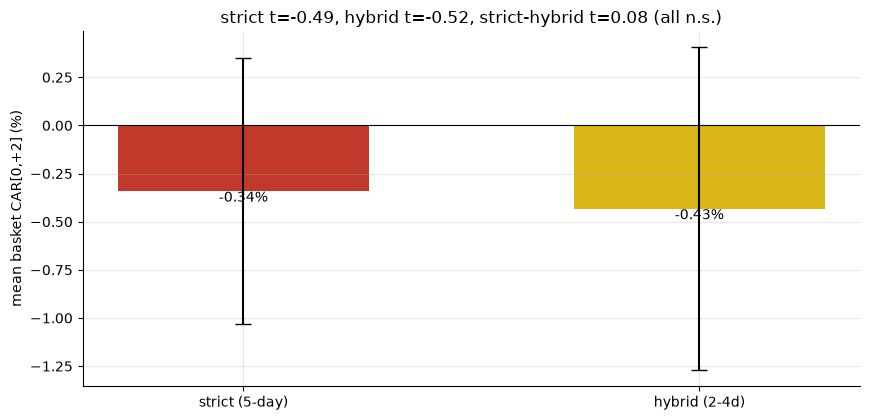

strict -0.34% (t=-0.49)  hybrid -0.43% (t=-0.52)  strict-hybrid t=0.08 — H2 wants >0


In [2]:
if HAVE_REAL:
    S = PANEL.loc[PANEL['strict'],'car'].values; H = PANEL.loc[~PANEL['strict'],'car'].values
    sm, hm = S.mean()*100, H.mean()*100
    sse, hse = S.std(ddof=1)/np.sqrt(len(S))*100, H.std(ddof=1)/np.sqrt(len(H))*100
    stt, htt = st.welch_t(S), st.welch_t(H); difft = st.welch_t(S,H)
else:
    sm, hm, stt, htt, difft = R['strict'][1], R['hybrid'][1], R['strict'][3], R['hybrid'][3], R['diff_t']
    sse, hse = abs(sm/max(abs(stt),1e-9)), abs(hm/max(abs(htt),1e-9))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['strict (5-day)','hybrid (2-4d)'], [sm, hm], yerr=[sse, hse], capsize=6,
       color=[RED, AMBER], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean basket CAR[0,+2] (%)')
ax.set_title(f'strict t={stt:.2f}, hybrid t={htt:.2f}, strict-hybrid t={difft:.2f} (all n.s.)')
for i,v in enumerate([sm,hm]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
plt.tight_layout(); plt.show()
print(f'strict {sm:+.2f}% (t={stt:.2f})  hybrid {hm:+.2f}% (t={htt:.2f})  strict-hybrid t={difft:.2f} — H2 wants >0')

> 💡 In plain words: strict mandates average **-0.34%** (t = -0.49), hybrids **-0.43%** (t = -0.52), and the strict−hybrid gap is **+0.09pp** at t = **0.08**. The believers' central prediction — a real mandate beats a soft one — has a point estimate of essentially zero.

### 4b · The decisive test — a placebo null sized to the event count

Draw 26 random basket windows 20,000 times; the histogram is the null for the mean CAR. The real reaction is the red line; the *p*-value is the two-sided tail mass.

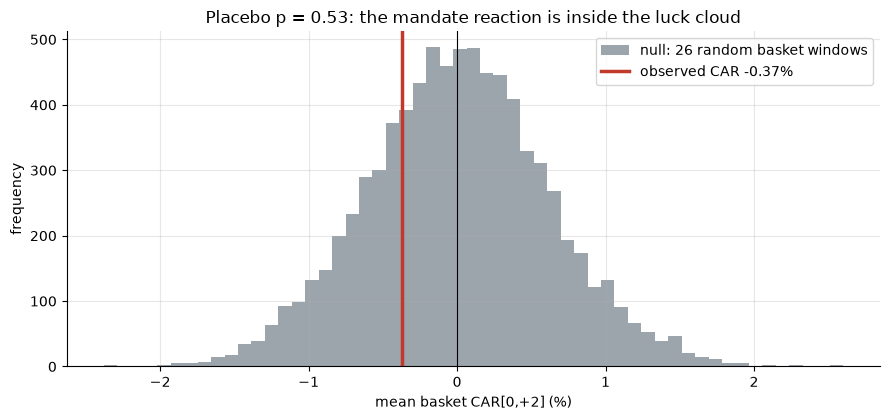

P[|random 26-window mean| >= |CAR|] = 0.527  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    null = st.placebo_car_dist(PRICES, MEM, k=len(PANEL), n_draws=8000)*100
    obs = PANEL['car'].mean()*100
    pval = st.placebo_pvalue(PANEL['car'].mean(), null/100)
else:
    rng=np.random.default_rng(750); null=rng.normal(0,0.55,8000); obs=R['allb'][1]; pval=R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_priced"]} random basket windows')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed CAR {obs:+.2f}%'); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean basket CAR[0,+2] (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the mandate reaction is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_priced"]}-window mean| >= |CAR|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **53%** of random 26-window draws match or beat the mandate reaction in magnitude. A real effect would push the red line into the tail; instead it sits dead-center. H₁ is **not supported** — the reaction is what a couple-dozen random calendar days look like on this basket.

### 4c · Robustness — window & benchmark

Shift the event window, and swap the benchmark to VNQ (so 'abnormal' means *relative to all REITs*). The all-events CAR stays a fraction of a percent with |t| well under 1 everywhere, and the strict−hybrid gap **flips sign** across windows — the fingerprint of noise, not signal.

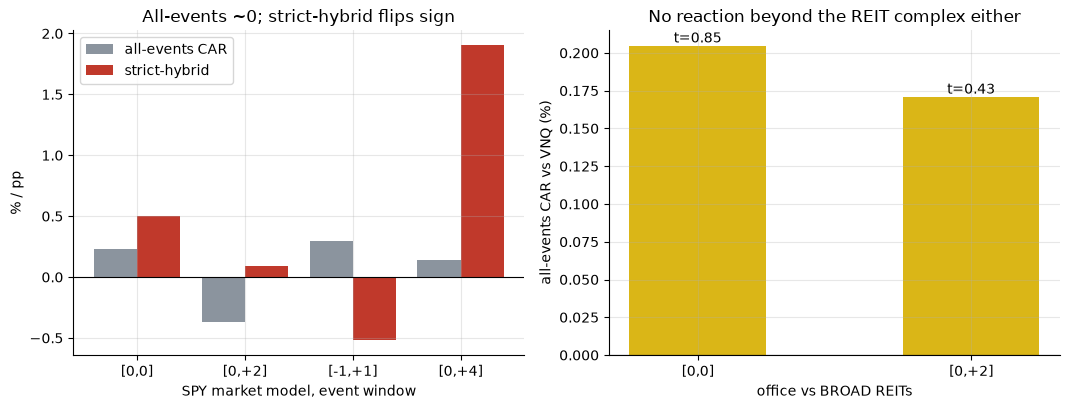

windows: [('[0,0]', 0.23, 0.69, 0.8), ('[0,+2]', -0.37, -0.69, 0.08), ('[-1,+1]', 0.3, 0.5, -0.37), ('[0,+4]', 0.14, 0.18, 1.32)]


In [4]:
if HAVE_REAL:
    rob=[]
    for w,lab in [((0,0),'[0,0]'),((0,2),'[0,+2]'),((-1,1),'[-1,+1]'),((0,4),'[0,+4]')]:
        pw=st.car_panel(PRICES,EVENTS,MEM,window=w); sw=st.summarize(pw)
        rob.append((lab, sw['all']['mean_pct'], sw['all']['t'], sw['diff_pct'], sw['diff_t']))
    vnq=[]
    for w,lab in [((0,0),'[0,0]'),((0,2),'[0,+2]')]:
        pw=st.car_panel(PRICES,EVENTS,MEM,benchmark='VNQ',window=w); sw=st.summarize(pw)
        vnq.append((lab, sw['all']['mean_pct'], sw['all']['t']))
else:
    rob=R['robust']; vnq=R['vnq']
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.8,4.2))
labs=[r[0] for r in rob]; means=[r[1] for r in rob]; difs=[r[3] for r in rob]; xx=np.arange(len(labs))
a1.bar(xx-.2, means, .4, color=GREY, label='all-events CAR'); a1.bar(xx+.2, difs, .4, color=RED, label='strict-hybrid')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(xx); a1.set_xticklabels(labs)
a1.set_ylabel('% / pp'); a1.set_xlabel('SPY market model, event window'); a1.set_title('All-events ~0; strict-hybrid flips sign'); a1.legend()
vl=[v[0] for v in vnq]; vm=[v[1] for v in vnq]; vt=[v[2] for v in vnq]; xx2=np.arange(len(vl))
bars=a2.bar(xx2, vm, .5, color=AMBER)
a2.axhline(0, c='k', lw=.8); a2.set_xticks(xx2); a2.set_xticklabels(vl)
a2.set_ylabel('all-events CAR vs VNQ (%)'); a2.set_xlabel('office vs BROAD REITs'); a2.set_title('No reaction beyond the REIT complex either')
for b,t in zip(bars,vt): a2.annotate(f't={t:.2f}',(b.get_x()+b.get_width()/2,b.get_height()),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('windows:', [(r[0], round(r[1],2), round(r[2],2), round(r[4],2)) for r in rob])

> 💡 In plain words: no event window makes the reaction significant (|t| < 1 everywhere), the strict−hybrid gap is +0.50pp on the news day but −0.52pp over [−1,+1] (sign-unstable = noise), and against VNQ the office basket doesn't move *relative to all REITs* either. The verdict doesn't hinge on any choice that could have rescued it.

### 4d · Faithful-engine & power control — we know the truth here

Deterministic per-event panels with a **planted** strict-bucket CAR edge: with **0 bps** the inference must NOT manufacture a strict>hybrid gap (a couple-dozen noisy events can't fake it); with a **+400 bps** planted edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large effects.

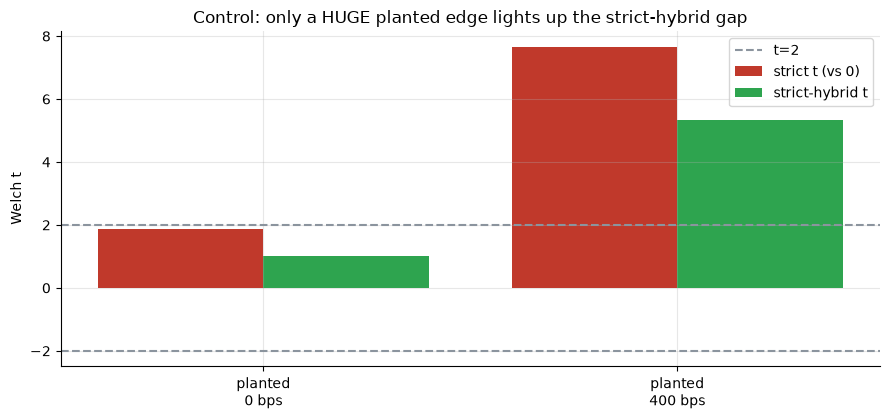

planted    0 bps: strict t=+1.87  strict-hybrid t=+1.01
planted  400 bps: strict t=+7.67  strict-hybrid t=+5.35


In [5]:
res = []
for edge in (0.0, 400.0):
    syn = data.synthetic_events(car_bps=edge, seed=750)
    stt = st.summarize_bucket(syn['strict_car'])['t']
    difft = st.welch_t(syn['strict_car'], syn['hybrid_car'])
    res.append((edge, stt, difft))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=[f'planted\n{int(e)} bps' for e,*_ in res]; xx=np.arange(len(labels))
stts=[r[1] for r in res]; diffs=[r[2] for r in res]
ax.bar(xx-.2, stts, .4, color=RED, label='strict t (vs 0)'); ax.bar(xx+.2, diffs, .4, color=GREEN, label='strict-hybrid t')
ax.axhline(2, ls='--', c=GREY, label='t=2'); ax.axhline(-2, ls='--', c=GREY)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t')
ax.set_title('Control: only a HUGE planted edge lights up the strict-hybrid gap'); ax.legend()
plt.tight_layout(); plt.show()
for e,s2,d2 in res: print(f'planted {int(e):>4} bps: strict t={s2:+.2f}  strict-hybrid t={d2:+.2f}')

> 💡 In plain words: with **no** planted edge the strict−hybrid *t* is **1.01** (the noise nudges the single strict bucket to t = 1.87, still short of 2, but the *difference* the claim rests on is cleanly null); only the **+400 bps** plant reaches strict−hybrid *t* **5.35**. So the machinery is honest, and the real-tape strict−hybrid *t* of **0.08** is exactly what *no effect* looks like through a 26-event keyhole.

## 5 · The verdict

- **Signal `NONE`** — all-events basket CAR **-0.37%** at Welch **t = -0.69** / placebo **p = 0.53**; strict−hybrid **+0.09pp** at **t = 0.08**; no window or benchmark (SPY/VNQ) clears |t| ~1. Indistinguishable from zero, faintly the wrong sign for a pop. **Survivorship** named on this axis and pointing *toward* the null (worst landlords delisted).
- **Tradability `MIRAGE`** — the 1-day-lag tradable CAR is **-0.33%** (**t = -0.47**), **-0.43%** net of 10 bps. Zero gross reaction on a rates/WFH-driven sector; no NAV-scale edge, not even sign-stable.
- **Office rebound on RTO? `NOT SUPPORTED`** — physical occupancy (Kastle proxy) refilled to ~half and plateaued, and the REITs priced none of it on any mandate. The office rebound is a macro/rates story, not a back-to-work-memo trade.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* mandate reaction have to be for a $k$-event study to detect it at $t=2$? At $k\approx 26$ on this basket's volatility you'd need a CAR several times larger than anything observed; the real reaction lives far below the detection floor — and the tradable version is negative on top.

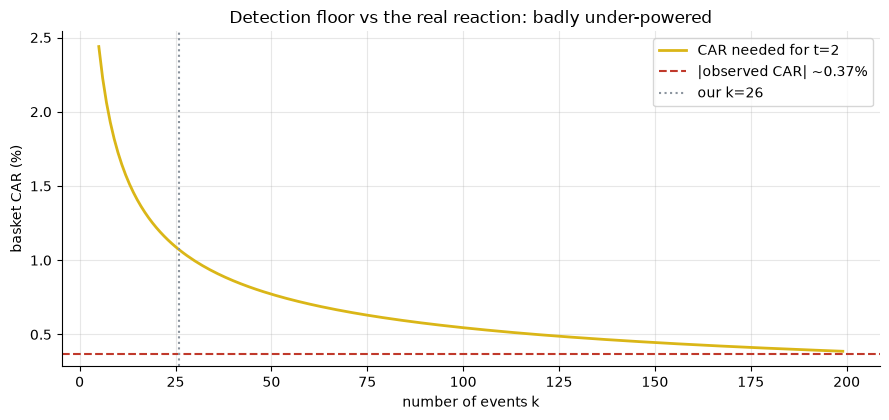

at k=26 you need ~1.07% CAR for t=2; observed ~0.37% -> under-powered


In [6]:
if HAVE_REAL:
    sd = PANEL['car'].std(ddof=1); obs = PANEL['car'].mean()
else:
    sd = 0.027; obs = R['allb'][1]/100
ks = np.arange(5, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='CAR needed for t=2')
ax.axhline(abs(obs)*100, c=RED, ls='--', label=f'|observed CAR| ~{abs(obs)*100:.2f}%')
ax.axvline(R['n_priced'], c=GREY, ls=':', label=f"our k={R['n_priced']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('basket CAR (%)')
ax.set_title('Detection floor vs the real reaction: badly under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_priced'])*100
print(f'at k={R["n_priced"]} you need ~{need:.2f}% CAR for t=2; observed ~{abs(obs)*100:.2f}% -> under-powered')

> 💡 In plain words: the amber curve is the **minimum detectable CAR**; the red line is what we see. They don't meet until $k$ is many times larger than the RTO calendar will ever deliver — and even a *real* reaction wouldn't pay, because the only version you can enter (next-day) is **negative**. There is no sizing, threshold, or window that manufactures an edge from ~26 events on a sector that trades on the 10-year yield. The rarity that makes each mandate a headline is exactly what makes the 'thesis' untestable and untradable.

## 7 · Going further

- **The twin.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model short-window event study on a labelled table, where the only real move is the un-tradable announcement instant.
- **The anecdote trap.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): the same small-sample / survivorship pathology on a table of corporate events.
- **Model the real driver.** Regress the office basket on Δ(10-year yield) and VNQ around each mandate; the RTO indicator should add ~nothing once rates and REIT-beta are in. That is the positive statement behind this null: offices are a *rates + structural-vacancy* asset.

*The reproducible core is offline and deterministic; the RTO calendar is hardcoded and the priced basket is survivor-biased (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*